Download Stock Data:

In [ ]:
import yfinance as yf

In [ ]:
stock_data = yf.download('NVDA', start='2014-06-27', end='2060-10-10')
stock_data

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,,
2014-06-27,0.437348,0.459500,0.462250,0.455750,0.458500,302820000
2014-06-30,0.441155,0.463500,0.464750,0.457750,0.457750,180512000
2014-07-01,0.446152,0.468750,0.471500,0.461500,0.463000,321180000
2014-07-02,0.444486,0.467000,0.469000,0.464250,0.467000,179284000
2014-07-03,0.448531,0.471250,0.472500,0.462750,0.462750,136892000
...,...,...,...,...,...,...
2024-11-29,138.240479,138.250000,139.350006,136.050003,136.779999,141863200
2024-12-02,138.620453,138.630005,140.449997,137.820007,138.830002,171682800


Scale the Data:

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

In [ ]:
scaled_data = scaler.fit_transform(stock_data['Close'].values.reshape(-1, 1))

Create Datasets:

In [ ]:
import numpy as np

def create_datasets(data, time_step):
  x, y = [], []
  for i in range(len(data)-time_step-1):
    x.append(data[i:(i+time_step), 0])
    y.append(data[i + time_step, 0])
  return np.array(x), np.array(y)

In [ ]:
time_step = 100
x, y = create_datasets(scaled_data, time_step)

In [ ]:
train_size = 0.8

In [ ]:
x_train, x_test = x[:int(x.shape[0]*train_size)], x[int(x.shape[0]*train_size):]
y_train, y_test = y[:int(y.shape[0]*train_size)], y[int(y.shape[0]*train_size):]

Build and Train LSTM Model:

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(64))
model.add(Dense(64))
model.add(Dense(1))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train,y_train,epochs=10,batch_size=64)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - loss: 0.0013
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 4.6230e-05
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 3.4883e-05
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 3.1805e-05
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - loss: 2.5617e-05
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - loss: 3.2997e-05
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - loss: 2.6658e-05
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 2.7784e-05
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - loss: 3.3519e-05
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 2.3287e-05


Evaluate Model and Make Predictions:

In [ ]:
test_loss = model.evaluate(x_test, y_test)
test_loss

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 8.5003e-04


0.0027825403958559036

In [ ]:
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [ ]:
original_data = stock_data['Close'].values
predicted_data = np.empty_like(original_data)
predicted_data[:] = np.nan
predicted_data[-len(predictions):] = predictions.reshape(-1,1)

Plot the Results:

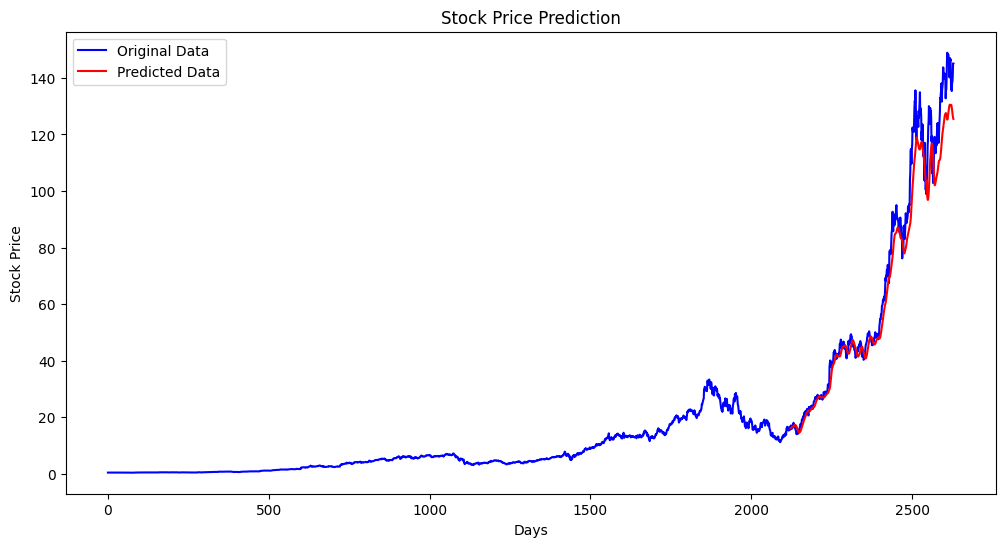

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.figure(figsize=(12, 6))
plt.plot(original_data, color='blue', label='Original Data')
plt.plot(predicted_data, color='red', label='Predicted Data')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()

In [ ]:
new_prediction = model.predict(x_test[-90:])
new_prediction = scaler.inverse_transform(new_prediction)
predicted_data = np.append(predicted_data, new_prediction)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


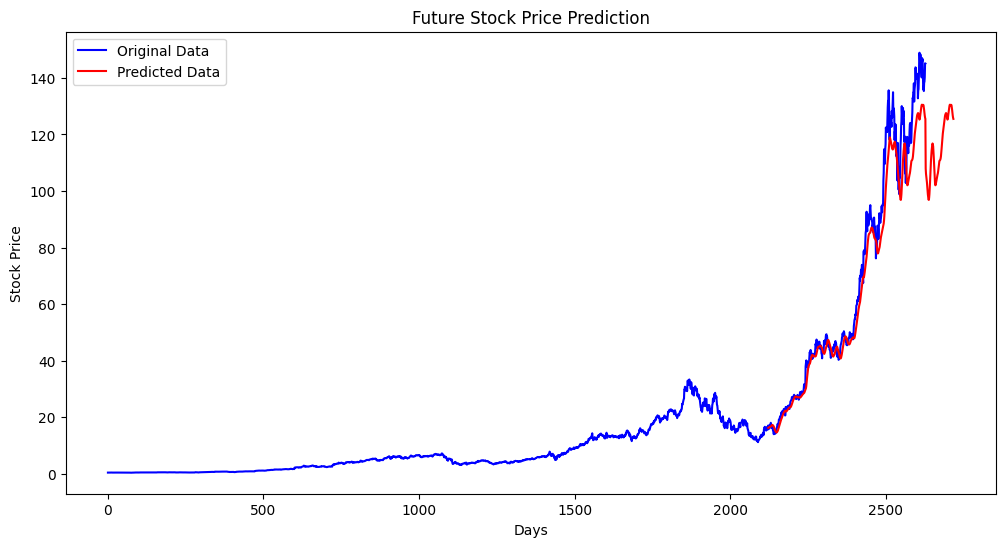

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(original_data, color='blue', label='Original Data')
plt.plot(predicted_data, color='red', label='Predicted Data')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Future Stock Price Prediction')
plt.legend()
plt.show()

In [ ]:
stock_data.index

DatetimeIndex(['2014-06-27', '2014-06-30', '2014-07-01', '2014-07-02',
               '2014-07-03', '2014-07-07', '2014-07-08', '2014-07-09',
               '2014-07-10', '2014-07-11',
               ...
               '2024-11-21', '2024-11-22', '2024-11-25', '2024-11-26',
               '2024-11-27', '2024-11-29', '2024-12-02', '2024-12-03',
               '2024-12-04', '2024-12-05'],
              dtype='datetime64[ns]', name='Date', length=2629, freq=None)